## Introduction to ML - 

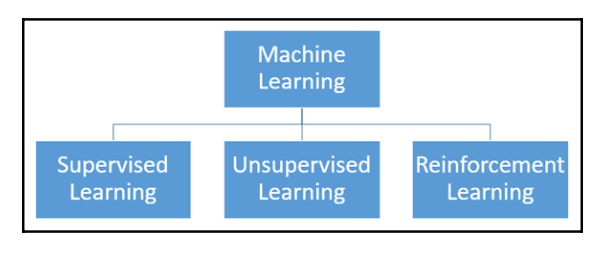

* __Supervised learning__: Supervised learning algorithms involve training the model using labeled data. The training dataset contains values of independent variables (also called a feature set) and the corresponding values of dependent variables. The algorithm analyzes these values and tries to learn a function that maps the independent variables to the dependent variables. Some widely used supervised learning algorithms include linear regression, k-nearest neighbor, decision tree, random forest, SVMs, Naive Bayes, and so on.

* __Unsupervised learning__: Unsupervised learning algorithms involve training the model using unlabeled data. The training process involves studying the dataset to understand the underlying structure of the data. Unsupervised learning is mostly used to cluster data and to perform anomaly detection by analyzing a data point with respect to other data points in the training set. Popular unsupervised algorithms include k-means, k-medoids, BIRCH, DBSCAN, and so on.

* __Reinforcement learning__: Reinforcement learning algorithms involve training the model based on simulations wherein the model learns based on the rewards that it receives for performing certain actions. Examples of popular reinforcement learning algorithms include Q-learning, SARSA, and so on.

## Data preprocessing

Training data needs to adhere to certain rules to be of any value to the model. Poorly processed data is guaranteed to train low accuracy models. It should be noted that data preprocessing is a vast field and that we may be required to perform various preprocessing steps based on the data we are working with.

In [4]:
# pip install seaborn
import seaborn as sns

tips_df = sns.load_dataset('tips')
tips_df.head()

Matplotlib is building the font cache; this may take a moment.


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### NaN values
Data needs to be checked for NaN values after it's been imported. This is important because undetected NaN values can be very problematic for training and may even cause the training process to fail. 

In [11]:
#Check if NaN value in the dataset
tips_df.isnull().values.any()

np.False_

In [12]:
#Check if NaN value in the columns
tips_df.isnull().any()

total_bill    False
tip           False
sex           False
smoker        False
day           False
time          False
size          False
dtype: bool

In [13]:
#Check if NaN value in the rows
tips_df.isnull().any(axis=1)

0      False
1      False
2      False
3      False
4      False
       ...  
239    False
240    False
241    False
242    False
243    False
Length: 244, dtype: bool

Among the many methods for addressing NaN values, some of the popular methods are as follows:
* Dropping the row/column with NaN value(s). The dropna() function can be
used to drop rows/columns containing NaN value(s).
* Replacing the NaN value with another value. The value could be the previous value, the next value, zero, the mean of the row or column, and so on. This can be done using the fillna() function.

### Label encoding and one-hot encoding
In the Tips dataset, we can see that there are four categorical variables, namely sex, smoker, day, and time. The values of these variables are non-numeric, which is problematic because the mathematical models underpinning our ML system only understand numeric inputs. Therefore, we need to convert these non-numeric values into numeric values, which can be done by label encoding.

In [14]:
from sklearn.preprocessing import LabelEncoder
label_encoding = LabelEncoder()
tips_df.iloc[:,[2,3,4,5]] = tips_df.iloc[:,[2,3,4,5]].apply(label_encoding.fit_transform)
tips_df.head()

/var/folders/0b/ydxznqxn43d0k3zwr07rtz480000gn/T/ipykernel_3474/2567558017.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0
1      1
2      1
3      1
4      0
      ..
239    1
240    0
241    1
242    1
243    0
Name: sex, Length: 244, dtype: int64' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  tips_df.iloc[:,[2,3,4,5]] = tips_df.iloc[:,[2,3,4,5]].apply(label_encoding.fit_transform)
/var/folders/0b/ydxznqxn43d0k3zwr07rtz480000gn/T/ipykernel_3474/2567558017.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      0
1      0
2      0
3      0
4      0
      ..
239    0
240    1
241    1
242    0
243    0
Name: smoker, Length: 244, dtype: int64' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  tips_df.iloc[:,[2,3,4,5]] = tips_df.iloc[:,[2,3,4,5

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


### Another way to convert categorical text data into numbers

In [29]:
#visualizing the encodings in label encoding
label_encoding = LabelEncoder() # creates an instance of the LabelEncoder class.
col_fit = label_encoding.fit(tips_df["day"]) # fits the label encoder to the "day" column of the tips_df DataFrame, learning the unique categories in alphabetically sorted order present in that column and assigning them integer labels.
dict(zip(col_fit.classes_, col_fit.transform(col_fit.classes_))) 

{np.int64(0): np.int64(0),
 np.int64(1): np.int64(1),
 np.int64(2): np.int64(2),
 np.int64(3): np.int64(3)}

`col_fit.classes_`: This returns an array of the unique words found (the keys)\
`.col_fit.transform(col_fit.classes_)`: This takes those words and converts them into their assigned numbers (the values)

Insights : we encoded Friday as 0 and Saturday as 1. When we feed these values to a mathematical model, it will consider these values as numbers and therefore will consider 1 to be greater than 0, which is not a correct treatment of these values.

To address this issue, we can use <u>_one-hot encoding_</u>, which splits a column with categorical variables into multiple columns, with each new column corresponding to a unique value of the categorical variable.


In the preceding example, using one-hot encoding on the day column will result in four columns (Fri, Sat, Sun, Thur), with each column containing only 0 or 1, depending on whether the unique value occurred in a given row. 

### One Hot encoding

In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
oh_encoding = ColumnTransformer([('OneHotEncoding', OneHotEncoder(),  [2,3,4,5])],remainder='passthrough')
tips_df_ohe = oh_encoding.fit_transform(tips_df)
tips_df_ohe

array([[ 1.  ,  0.  ,  1.  , ..., 16.99,  1.01,  2.  ],
       [ 0.  ,  1.  ,  1.  , ..., 10.34,  1.66,  3.  ],
       [ 0.  ,  1.  ,  1.  , ..., 21.01,  3.5 ,  3.  ],
       ...,
       [ 0.  ,  1.  ,  0.  , ..., 22.67,  2.  ,  2.  ],
       [ 0.  ,  1.  ,  1.  , ..., 17.82,  1.75,  2.  ],
       [ 1.  ,  0.  ,  1.  , ..., 18.78,  3.  ,  2.  ]], shape=(244, 13))

Here is the breakdown:
1. The `SetupOneHotEncoder`: The tool that converts a column like ["Male", "Female"] into two separate columns.ColumnTransformer: This is the "manager." It allows you to apply different transformations to specific columns while leaving others alone.
2. `oh_encoding = ColumnTransformer(...)` You are defining a recipe here. It takes a list of `tuples: (name, transformer, columns)`.
    * `'OneHotEncoding'`: Just a nickname for this step.
    * `OneHotEncoder()`: The engine that will do the work.
    * `[2, 3, 4, 5]`: These are the index positions of the columns in tips_df you want to encode (e.g., sex, smoker, day, time).
    * `remainder='passthrough'`: This is crucial. It tells Python: "Don't drop the other columns (like 'total_bill' or 'tip'); just keep them as they are and attach them to the end."
3. `tips_df_ohe = oh_encoding.fit_transform(tips_df)` This executes the plan.
    * `fit`: It learns all the unique categories in columns 2, 3, 4, and 5.
    * `transform`: It deletes the original text columns and replaces them with multiple columns of 1s and 0s.
    * The result, `tips_df_ohe`, is usually returned as a NumPy array (or a sparse matrix), not a friendly-looking DataFrame.
4. Why use this instead of Label Encoding?\
In your previous example, "Thursday" was 3 and "Friday" was 0. A machine learning model might think Thursday is "mathematically bigger" than Friday. One-Hot Encoding solves this by giving every category its own column, so no category is "ranked" higher than another.\
__Summary of the result__:\
The output tips_df_ohe will be a wide grid of numbers. If column 2 was "Sex" (Male/Female), it is now two columns. If a row was "Male," those two columns will look like [1, 0].

### Data standardization
Standardization is a data preprocessing step that attempts to equalize the range of values for all the columns. This is important because most ML algorithms require data to be in the same range, and non-uniform value ranges can impair the model's ability to learn from the data. For example, if all the columns in a dataset are in the range of [0, 10], whereas values in one column range from [-1000, 1000], then there is a high likelihood that this column will have a disproportionate influence over the model and that the trained model will be pretty much a one-to-one mapping between this column and the dependent variable. 

The two most popular techniques are min-max standardization and z-score standardization.

* Min-max standardization

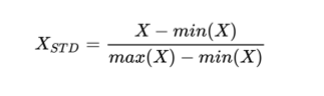

Here, X is the vector representing the column. Each value in the column is subtracted by the minimum value of the column and divided by the column range. Post transformation, the range of the column becomes [0, 1].

* Z-score standardization

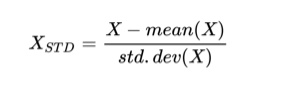

Here, X is the vector representing the column. The z-score is the numerical measurement of how many standard deviations away a value from the mean of the group is. Post transformation, most values are expected to fall in the range of [-3, 3].


In [32]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
tips_df_std = minmax.fit_transform(tips_df_ohe)
tips_df_std

array([[1.        , 0.        , 1.        , ..., 0.29157939, 0.00111111,
        0.2       ],
       [0.        , 1.        , 1.        , ..., 0.1522832 , 0.07333333,
        0.4       ],
       [0.        , 1.        , 1.        , ..., 0.3757855 , 0.27777778,
        0.4       ],
       ...,
       [0.        , 1.        , 0.        , ..., 0.41055718, 0.11111111,
        0.2       ],
       [0.        , 1.        , 1.        , ..., 0.30896523, 0.08333333,
        0.2       ],
       [1.        , 0.        , 1.        , ..., 0.32907415, 0.22222222,
        0.2       ]], shape=(244, 13))

In [33]:
from sklearn.preprocessing import StandardScaler
zs = StandardScaler()
tips_df_std = zs.fit_transform(tips_df_ohe)
tips_df_std

array([[ 1.34335316e+00, -1.34335316e+00,  7.84789169e-01, ...,
        -3.14711305e-01, -1.43994695e+00, -6.00192629e-01],
       [-7.44405889e-01,  7.44405889e-01,  7.84789169e-01, ...,
        -1.06323531e+00, -9.69205340e-01,  4.53382921e-01],
       [-7.44405889e-01,  7.44405889e-01,  7.84789169e-01, ...,
         1.37779900e-01,  3.63355539e-01,  4.53382921e-01],
       ...,
       [-7.44405889e-01,  7.44405889e-01, -1.27422758e+00, ...,
         3.24629502e-01, -7.22971264e-01, -6.00192629e-01],
       [-7.44405889e-01,  7.44405889e-01,  7.84789169e-01, ...,
        -2.21286504e-01, -9.04025732e-01, -6.00192629e-01],
       [ 1.34335316e+00, -1.34335316e+00,  7.84789169e-01, ...,
        -1.13228903e-01,  1.24660453e-03, -6.00192629e-01]],
      shape=(244, 13))

### The Naive Bayes algorithm

The Bayes' theorem can be represented as follows:

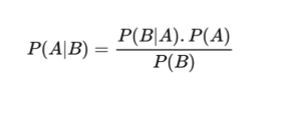

Here, A, B are events:
* `P(A|B)` is the probability of A given B, while `P(B|A)` is the probability of B given
A.
* `P(A)` is the independent probability of A, while `P(B)` is the independent
probability of B.


Let's say we have the following fictitious dataset containing information about applications to Ivy League schools. The independent variables in the dataset are the applicant's SAT score, applicant's GPA, and information regarding whether the applicant's parents are alumni to an Ivy League school. The dependent variable is the outcome of the application. Based on this data, we are interested in calculating the likelihood of an applicant getting admission to an Ivy League school given that their SAT score is greater than 1,500, their GPA is greater than 3.2, and their parents are not alumni:

| SAT Score | GPA | Alumni | Parents | Ivy League Admission? |
| :--- | :--- | :--- | :--- | :--- |
| 1,580 | 4.0 | 0 | 0 | 1 |
| 1,450 | 3.1 | 1 | 1 | 1 |
| 1,480 | 3.6 | 0 | 0 | 0 |
| 1,410 | 3.33 | 0 | 0 | 0 |
| 1,280 | 3.0 | 1 | 1 | 1 |
| 1,440 | 3.7 | 0 | 0 | 0 |
| 1,560 | 3.9 | 1 | 1 | 1 |
| >1,500 | >3.2 | 0 | 0 | ? |

P(Ivy League|(SAT>1500, GPA>3.2, AP=0))
Using Bayes' theorem, the preceding probabilistic expression can be represented as follows:

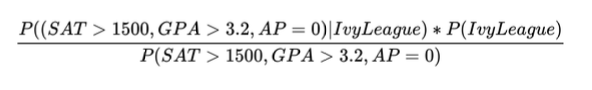

However, for bigger datasets, calculating joint probability can get a bit challenging. To get around this problem, we use Naive Bayes, which assumes that all the features are independent of each other, so the joint probability is simply the product of independent probabilities. This assumption is naive because it is almost always wrong. Even in our example, an applicant having a high SAT score is more likely to have a high GPA, so these two events are not independent. However, the Naive Bayes assumption has been proved to work well for classification problems.

Using the Naive Bayes assumption we provided in the previous example, the Bayes' theorem expression can be written as follows:

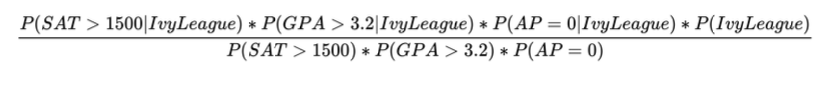

This equation can easily be solved by calculating the respective probabilities. The numerator can be calculated as follows:\
(2/4) * (2/4) * (1/4) * (4/7) 

The denominator can be calculated as follows:\
(2/7) * (5/7) * (4/7)

By calculating the ratio of the products, the final answer as __0.306__, which can be rounded to 0. So, based on the data, Naive Bayes calculation predicts that an applicant with a SAT score > 1,500, GPA > 3.2, and parents not being alumni is not likely to be admitted to Ivy League. This is an unfair world!